# Reference Generators

Reference generators produce a reference signal $r_k$ that encodes the desired system behaviour.
`h` always returns $r_k$ so the output can be fed directly into a controller block.

<a href="../f_h_functions.html">
    <img src="../../../_static/figures/block_reference.svg" />
</a>

## Stateless


### Constant
Generates a constant reference signal.
$r_k = r$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dynamicalnodes import DynamicalSystem


def constant_h(r: float) -> float:
    return r

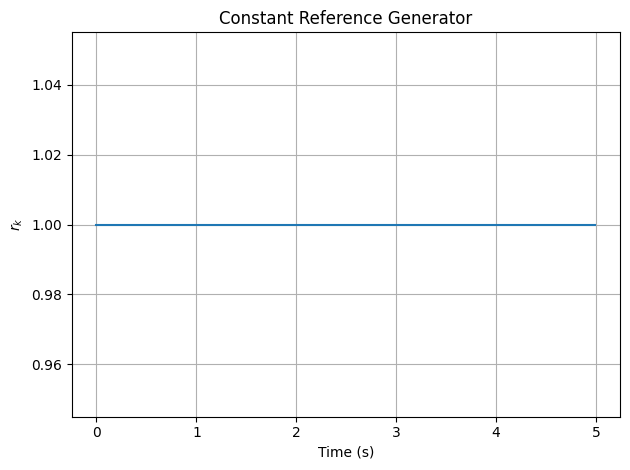

In [2]:
ref_constant = DynamicalSystem(h=constant_h)

r = 1.0
dt = 0.01
t_sim = np.arange(0, 5.0, dt)

r_log = []
for tk in t_sim:
    r_k = ref_constant.step(r=r)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, r_log)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$r_k$")
ax.set_title("Constant Reference Generator")
ax.grid(True)
plt.tight_layout()
plt.show()

### Sinusoid
Generates a sinusoidal reference signal with amplitude $A$ and angular frequency $\omega$ (rad/s).
$r_k = A \sin(\omega\, t_k)$, where $t_k$ is elapsed time in seconds.

In [3]:
def sin_wave_h(tk: float, A: float, omega: float) -> float:
    return A * np.sin(omega * tk)

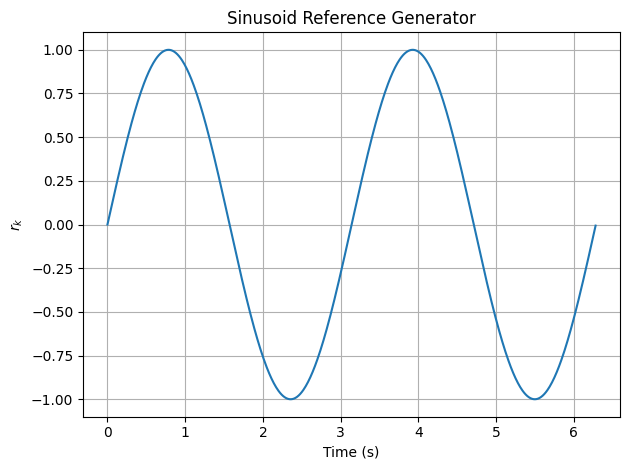

In [4]:
ref_sin_wave = DynamicalSystem(h=sin_wave_h)

A = 1.0        # amplitude
omega = 2.0    # angular frequency (rad/s)
dt = 0.01
t_sim = np.arange(0, 4 * np.pi / omega, dt)

r_log = []
for tk in t_sim:
    r_k = ref_sin_wave.step(tk=tk, A=A, omega=omega)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, r_log)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$r_k$")
ax.set_title("Sinusoid Reference Generator")
ax.grid(True)
plt.tight_layout()
plt.show()

### Square Wave
Generates a square wave reference signal with amplitude $A$ and period $T$ (seconds).
$r_k = A \operatorname{sgn}\!\left(\sin\!\left(\tfrac{2\pi}{T} t_k\right)\right)$

In [5]:
def square_wave_h(tk: float, A: float, T: float) -> float:
    return A * np.sign(np.sin(2 * np.pi / T * tk))

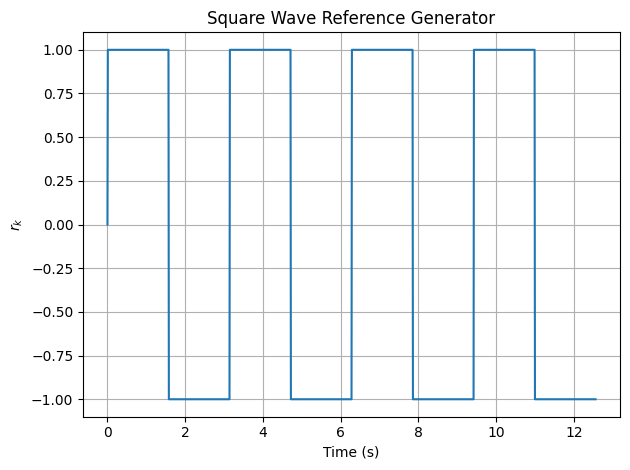

In [6]:
ref_square_wave = DynamicalSystem(h=square_wave_h)

A = 1.0    # amplitude
T = np.pi  # period (s)
dt = 0.01
t_sim = np.arange(0, 4 * T, dt)

r_log = []
for tk in t_sim:
    r_k = ref_square_wave.step(tk=tk, A=A, T=T)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, r_log)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$r_k$")
ax.set_title("Square Wave Reference Generator")
ax.grid(True)
plt.tight_layout()
plt.show()

### Ramp
Generates a linearly increasing reference signal with slope $m$ (units/s).
$r_k = m\, t_k$

In [7]:
def ramp_h(tk: float, m: float) -> float:
    return m * tk

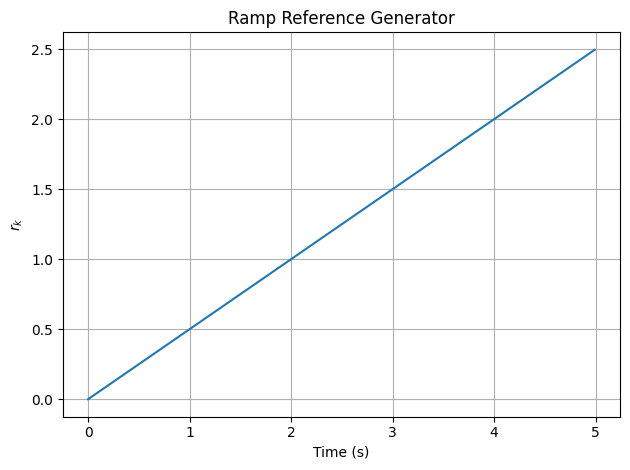

In [8]:
ref_ramp = DynamicalSystem(h=ramp_h)

m = 0.5    # slope (units/s)
dt = 0.01
t_sim = np.arange(0, 5.0, dt)

r_log = []
for tk in t_sim:
    r_k = ref_ramp.step(tk=tk, m=m)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, r_log)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$r_k$")
ax.set_title("Ramp Reference Generator")
ax.grid(True)
plt.tight_layout()
plt.show()

### Step
Generates a step reference signal that jumps from $0$ to $A$ at $t = t_{\text{step}}$.
$r_k = \begin{cases} A & t_k \ge t_{\text{step}} \\ 0 & \text{otherwise} \end{cases}$

In [9]:
def step_h(tk: float, A: float, t_step: float) -> float:
    return A if tk >= t_step else 0.0

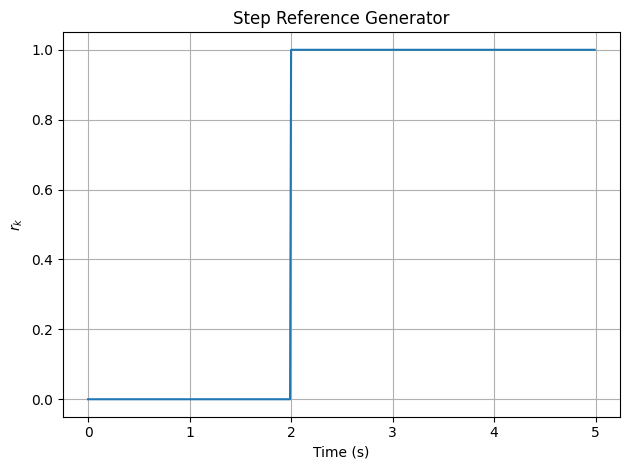

In [10]:
ref_step = DynamicalSystem(h=step_h)

A = 1.0
t_step = 2.0    # step onset (s)
dt = 0.01
t_sim = np.arange(0, 5.0, dt)

r_log = []
for tk in t_sim:
    r_k = ref_step.step(tk=tk, A=A, t_step=t_step)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, r_log)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$r_k$")
ax.set_title("Step Reference Generator")
ax.grid(True)
plt.tight_layout()
plt.show()

## Stateful

### Latch
Holds the last captured value until a boolean `trigger` goes high, at which point it latches the new input `u`.
$$x_{k+1} = \begin{cases} u_k & \text{trigger}_k \\ x_k & \text{otherwise} \end{cases}, \qquad r_k = x_k$$

In [11]:
def latch_f(x_k: float, u: float, trigger: bool) -> float:
    return u if trigger else x_k


def latch_h(x_k: float) -> float:
    return x_k

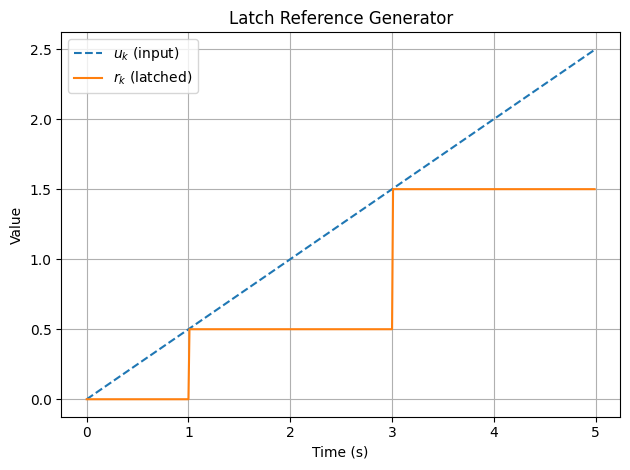

In [12]:
ref_latch = DynamicalSystem(f=latch_f, h=latch_h)

dt = 0.01
t_sim = np.arange(0, 5.0, dt)
trigger_times = {1.0, 3.0}

x_k = 0.0
u_log, r_log = [], []
for tk in t_sim:
    trigger = any(abs(tk - t) < dt / 2 for t in trigger_times)
    u = 0.5 * tk
    x_k, r_k = ref_latch.step(x_k=x_k, u=u, trigger=trigger)
    u_log.append(u)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, u_log, linestyle="--", label="$u_k$ (input)")
ax.plot(t_sim, r_log, label="$r_k$ (latched)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Value")
ax.set_title("Latch Reference Generator")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Setpoint
Holds a setpoint value and updates it whenever a new one is provided.
Pass `setpoint=value` to update; omit it to hold the current value.
$$x_{k+1} = \begin{cases} \text{setpoint}_k & \text{if provided} \\ x_k & \text{otherwise} \end{cases}, \qquad r_k = x_k$$

In [13]:
def setpoint_f(x_k: float, setpoint: float = None) -> float:
    return setpoint if setpoint is not None else x_k


def setpoint_h(x_k: float) -> float:
    return x_k

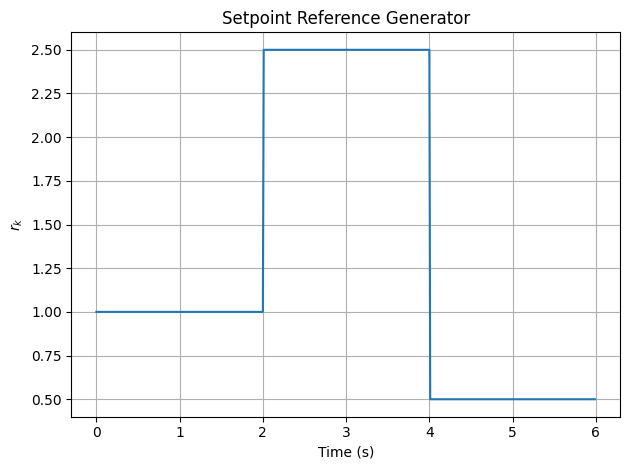

In [14]:
ref_setpoint = DynamicalSystem(f=setpoint_f, h=setpoint_h)

dt = 0.01
t_sim = np.arange(0, 6.0, dt)
updates = {2.0: 2.5, 4.0: 0.5}     # {time: new_setpoint}

x_k = 1.0   # initial setpoint
r_log = []
for tk in t_sim:
    new_sp = next((v for t, v in updates.items() if abs(tk - t) < dt / 2), None)
    kwargs = {"x_k": x_k} if new_sp is None else {"x_k": x_k, "setpoint": new_sp}
    x_k, r_k = ref_setpoint.step(**kwargs)
    r_log.append(r_k)

fig, ax = plt.subplots()
ax.plot(t_sim, r_log)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$r_k$")
ax.set_title("Setpoint Reference Generator")
ax.grid(True)
plt.tight_layout()
plt.show()